In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

import galess.LensStat.lens_stat as ls
# import galess.Utils.ls_utils as utils
# import galess.Plots.lens_plot as lens_plot
# import galess.HOD.HOD as HOD

path_root = os.path.split(os.path.abspath(''))[0]
sys.path.append(str(path_root) + '/galess/LensStat/')
sys.path.append(str(path_root) + '/galess/Utils/')
sys.path.append(str(path_root) + '/galess/Plots/')
sys.path.append(str(path_root) + '/galess/HOD/')
sys.path.append(str(path_root) + '/galess/RareLensStat/')
# import lens_stat as ls
import ls_utils as utils
import lens_plot
import lens_plot_paper
import rare_lens_stat as rls

h = 0.7
___PLOT_FOR_KEYNOTE___ = 0

M_array     = np.linspace(-13 , -25 , 25)
sigma_array = np.linspace(100 , 400 , 31)
zl_array    = np.arange(0.  , 2.5 , 0.1)
zs_array    = np.arange(0.  , 5.4 , 0.2)

min_SNR     = 20
arc_mu_thr  = 3

surveys_titles = [
     'COSMOS HST i band',
     'CFHTLS i band',
     'SUBARU HSC SuGOHI i band',
     'DES i band',
     'COSMOS Web F115W', 'COSMOS Web F150W', 'COSMOS Web F277W',
     'PEARLS NEP F115W', 'PEARLS NEP F150W', 'PEARLS NEP F277W',
     'EUCLID Wide VIS', 'EUCLID Wide Y', 'EUCLID Wide J', 'EUCLID Wide H',
     'Roman HLWA J',
     'LSST i band', 'LSSTsinglevisit i band']

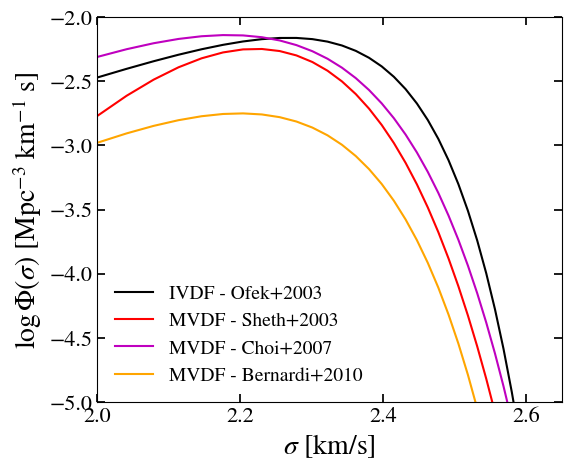

In [27]:
IVDF_0 = ls.Phi_vel_disp_Capelo_Natarajan(sigma_array, 0, VDF_NAME = 'IVDF')
MVDF_0 = ls.Phi_vel_disp_Capelo_Natarajan(sigma_array, 0, VDF_NAME = 'MVDF')
MVDF_Choi = ls.Phi_vel_disp_SDSS(sigma_array, 0)

VDF_z0_ARGS_B =  0.179*1e-2, 166.5, 2.54, 2.93
MVDF_Bernardi = ls.Phi_vel_disp_Capelo_Natarajan(sigma_array, 0, VDF_z0_ARGS = VDF_z0_ARGS_B, VDF_NAME = 'MVDF')

line_c, cmap_c, _col_, col_A, col_B, col_C, col_D, fn_prefix = lens_plot.set_plt_param(___PLOT_FOR_KEYNOTE___)
fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharex=False, sharey=False)
plt.subplots_adjust(wspace=.23, hspace=.2)
ax.plot(np.log10(sigma_array), np.log10(IVDF_0 / (0.7)**3 * sigma_array), label = 'IVDF - Ofek+2003' , color = col_A)
ax.plot(np.log10(sigma_array), np.log10(MVDF_0 / (0.7)**3 * sigma_array), label = 'MVDF - Sheth+2003', color = col_B)
ax.plot(np.log10(sigma_array), np.log10(MVDF_Choi / (0.7)**3 * sigma_array), label = 'MVDF - Choi+2007' , color = col_C)
ax.plot(np.log10(sigma_array), np.log10(MVDF_Bernardi * sigma_array), label = 'MVDF - Bernardi+2010' , color = col_D)

ax.set_xlabel(r'$\sigma$ [km/s]', fontsize=20)
ax.set_ylabel(r'$\log \Phi(\sigma)$ [Mpc$^{-3}$ km$^{-1}$ s]', fontsize=20)
# ax.set_yscale('log')
ax.set_xlim((2, 2.65))
ax.set_ylim((-5, -2))
ax.legend(fontsize=14)
plt.show()